In [3]:
import pandas as pd

# Загружаем файлы
matches = pd.read_csv(r'C:\Users\egor-\Downloads\archive (16)\match.csv')
players = pd.read_csv(r'C:\Users\egor-\Downloads\archive (16)\players.csv')

# Проверяем, что загрузилось
print(matches.head())
print(players.head())

   match_id  start_time  duration  tower_status_radiant  tower_status_dire  \
0         0  1446750112      2375                  1982                  4   
1         1  1446753078      2582                     0               1846   
2         2  1446764586      2716                   256               1972   
3         3  1446765723      3085                     4               1924   
4         4  1446796385      1887                  2047                  0   

   barracks_status_dire  barracks_status_radiant  first_blood_time  game_mode  \
0                     3                       63                 1         22   
1                    63                        0               221         22   
2                    63                       48               190         22   
3                    51                        3                40         22   
4                     0                       63                58         22   

   radiant_win  negative_votes  positive_vot

In [6]:
import pandas as pd

# Загружаем данные
matches = pd.read_csv(r'C:\Users\egor-\Downloads\archive (16)\match.csv')
players = pd.read_csv(r'C:\Users\egor-\Downloads\archive (16)\players.csv')

# 1. Группируем игроков по матчу и команде (Radiant: player_slot < 128)
players['team'] = players['player_slot'].apply(lambda x: 'radiant' if x < 128 else 'dire')

team_stats = players.groupby(['match_id', 'team'])[['kills', 'deaths', 'assists', 'gold_per_min', 'xp_per_min']].sum().reset_index()

# 2. Добавляем результат матча (radiant_win = 1 если победил Radiant)
team_stats = team_stats.merge(matches[['match_id', 'radiant_win']], on='match_id', how='left')

# 3. Определяем, была ли команда победителем
team_stats['is_winner'] = ((team_stats['team'] == 'radiant') & (team_stats['radiant_win'] == 1)) | \
                          ((team_stats['team'] == 'dire') & (team_stats['radiant_win'] == 0))

# 4. Группируем по статусу (победитель/проигравший) и считаем средние
winner_stats = team_stats[team_stats['is_winner'] == True].drop(columns=['team', 'radiant_win', 'is_winner']).mean()
loser_stats = team_stats[team_stats['is_winner'] == False].drop(columns=['team', 'radiant_win', 'is_winner']).mean()

# 5. Собираем результат в таблицу
result = pd.DataFrame({'Победитель': winner_stats, 'Проигравший': loser_stats}).T
print(result.round(2))

             match_id  kills  deaths  assists  gold_per_min  xp_per_min
Победитель    24999.5  44.68   30.78    70.44       2405.12     2521.61
Проигравший   24999.5  29.36   46.02    47.18       1745.85     1978.12


In [8]:
import pandas as pd

# Загружаем player_time (поминутная статистика игроков)
player_time = pd.read_csv(r'C:\Users\egor-\Downloads\archive (16)\player_time.csv')
print("player_time columns:", player_time.columns.tolist())
print(player_time.head())

# Загружаем objectives (взятие башен, рошан и т.д.)
objectives = pd.read_csv(r'C:\Users\egor-\Downloads\archive (16)\objectives.csv')
print("\nobjectives columns:", objectives.columns.tolist())
print(objectives.head())

player_time columns: ['match_id', 'times', 'gold_t_0', 'lh_t_0', 'xp_t_0', 'gold_t_1', 'lh_t_1', 'xp_t_1', 'gold_t_2', 'lh_t_2', 'xp_t_2', 'gold_t_3', 'lh_t_3', 'xp_t_3', 'gold_t_4', 'lh_t_4', 'xp_t_4', 'gold_t_128', 'lh_t_128', 'xp_t_128', 'gold_t_129', 'lh_t_129', 'xp_t_129', 'gold_t_130', 'lh_t_130', 'xp_t_130', 'gold_t_131', 'lh_t_131', 'xp_t_131', 'gold_t_132', 'lh_t_132', 'xp_t_132']
   match_id  times  gold_t_0  lh_t_0  xp_t_0  gold_t_1  lh_t_1  xp_t_1  \
0         0      0         0       0       0         0       0       0   
1         0     60       409       0      63       142       1     186   
2         0    120       546       0     283       622       4     645   
3         0    180       683       1     314       927       9    1202   
4         0    240       956       1     485      1264      11    1583   

   gold_t_2  lh_t_2  ...  xp_t_129  gold_t_130  lh_t_130  xp_t_130  \
0         0       0  ...         0           0         0         0   
1       168       0  .

In [11]:
import pandas as pd

# Загрузка
player_time = pd.read_csv(r'C:\Users\egor-\Downloads\archive (16)\player_time.csv')
objectives = pd.read_csv(r'C:\Users\egor-\Downloads\archive (16)\objectives.csv')
matches = pd.read_csv(r'C:\Users\egor-\Downloads\archive (16)\match.csv')

# --- 1. Преобразуем player_time в длинный формат ---
slots = [0,1,2,3,4,128,129,130,131,132]
dfs = []
for slot in slots:
    df_slot = player_time[['match_id', 'times', f'gold_t_{slot}', f'lh_t_{slot}', f'xp_t_{slot}']].copy()
    df_slot.columns = ['match_id', 'times', 'gold', 'lh', 'xp']
    df_slot['player_slot'] = slot
    dfs.append(df_slot)
player_time_long = pd.concat(dfs, ignore_index=True)

# --- 2. Берём данные на 10-й минуте (600 секунд) ---
player_time_10 = player_time_long[player_time_long['times'] <= 660].groupby(['match_id', 'player_slot']).last().reset_index()
player_time_10['team'] = player_time_10['player_slot'].apply(lambda x: 'radiant' if x < 128 else 'dire')

# --- 3. Суммируем по командам ---
team_stats_10 = player_time_10.groupby(['match_id', 'team'])[['gold', 'lh', 'xp']].sum().reset_index()

# --- 4. Вычисляем разницу (Radiant - Dire) ---
pivot = team_stats_10.pivot(index='match_id', columns='team', values=['gold', 'lh', 'xp'])
# flatten columns
pivot.columns = [f'{metric}_{team}' for metric, team in pivot.columns]
pivot['gold_diff'] = pivot['gold_radiant'] - pivot['gold_dire']
pivot['xp_diff'] = pivot['xp_radiant'] - pivot['xp_dire']
pivot['lh_diff'] = pivot['lh_radiant'] - pivot['lh_dire']

# --- 5. Добавляем результат матча ---
pivot['radiant_win'] = pivot.index.map(matches.set_index('match_id')['radiant_win'])

# --- 6. Ранние события: первая кровь ---
first_blood = objectives[objectives['subtype'] == 'CHAT_MESSAGE_FIRSTBLOOD'].groupby('match_id')['time'].first().rename('first_blood_time')
pivot = pivot.join(first_blood, on='match_id')

# --- 7. Первая башня ---
tower_kills = objectives[objectives['subtype'] == 'CHAT_MESSAGE_TOWER_KILL'].copy()
first_tower = tower_kills.groupby('match_id').first().reset_index()[['match_id', 'time', 'team']]
first_tower.columns = ['match_id', 'first_tower_time', 'first_tower_team']
pivot = pivot.merge(first_tower, on='match_id', how='left')

# --- 8. Корреляции ---
print("=== КОРРЕЛЯЦИЯ РАННИХ ПОКАЗАТЕЛЕЙ С ПОБЕДОЙ ===")
corr = pivot[['gold_diff', 'xp_diff', 'lh_diff', 'first_blood_time', 'first_tower_time']].corrwith(pivot['radiant_win'])
print(corr.round(3))

print("\n=== СРЕДНЯЯ РАЗНИЦА ЗОЛОТА НА 10 МИНУТЕ ===")
print(pivot.groupby('radiant_win')['gold_diff'].mean())

print("\n=== ВРЕМЯ ПЕРВОЙ БАШНИ У ПОБЕДИТЕЛЕЙ И ПРОИГРАВШИХ ===")
print(pivot.groupby('radiant_win')['first_tower_time'].mean())

=== КОРРЕЛЯЦИЯ РАННИХ ПОКАЗАТЕЛЕЙ С ПОБЕДОЙ ===
gold_diff           0.373
xp_diff             0.354
lh_diff             0.234
first_blood_time    0.005
first_tower_time   -0.009
dtype: float64

=== СРЕДНЯЯ РАЗНИЦА ЗОЛОТА НА 10 МИНУТЕ ===
radiant_win
False   -1019.456250
True     1080.906102
Name: gold_diff, dtype: float64

=== ВРЕМЯ ПЕРВОЙ БАШНИ У ПОБЕДИТЕЛЕЙ И ПРОИГРАВШИХ ===
radiant_win
False    722.635940
True     719.394524
Name: first_tower_time, dtype: float64


In [14]:
import pandas as pd
import numpy as np

# Загрузка данных (предполагаем, что уже загружены)
# player_time, objectives, matches

# --- 1. Преобразуем player_time в длинный формат ---
slots = [0,1,2,3,4,128,129,130,131,132]
dfs = []
for slot in slots:
    df_slot = player_time[['match_id', 'times', f'gold_t_{slot}', f'lh_t_{slot}', f'xp_t_{slot}']].copy()
    df_slot.columns = ['match_id', 'times', 'gold', 'lh', 'xp']
    df_slot['player_slot'] = slot
    dfs.append(df_slot)
player_time_long = pd.concat(dfs, ignore_index=True)

# --- 2. Функция для получения данных на определённой минуте ---
def get_stats_at_time(minute):
    seconds = minute * 60
    df_time = player_time_long[player_time_long['times'] <= seconds].groupby(['match_id', 'player_slot']).last().reset_index()
    df_time['team'] = df_time['player_slot'].apply(lambda x: 'radiant' if x < 128 else 'dire')
    team_stats = df_time.groupby(['match_id', 'team'])[['gold', 'lh', 'xp']].sum().reset_index()
    # Создаём сводную таблицу с отдельными колонками для radiant и dire
    pivot = team_stats.pivot(index='match_id', columns='team', values=['gold', 'lh', 'xp'])
    # Сплющиваем мультииндекс
    pivot.columns = [f'{col[0]}_{col[1]}' for col in pivot.columns]
    # Добавляем разности
    pivot['gold_diff'] = pivot['gold_radiant'] - pivot['gold_dire']
    pivot['xp_diff'] = pivot['xp_radiant'] - pivot['xp_dire']
    pivot['lh_diff'] = pivot['lh_radiant'] - pivot['lh_dire']
    return pivot

# --- 3. Получаем данные на 5 и 10 минутах ---
stats_5 = get_stats_at_time(5)
stats_10 = get_stats_at_time(10)

# --- 4. Вычисляем темп роста (золото/опыт/ластхиты в минуту) между 5 и 10 минутами ---
gold_growth = (stats_10['gold_diff'] - stats_5['gold_diff']) / 5
xp_growth = (stats_10['xp_diff'] - stats_5['xp_diff']) / 5
lh_growth = (stats_10['lh_diff'] - stats_5['lh_diff']) / 5

# --- 5. Эффективность фарма: золото на один ластхит на 10 минуте ---
stats_10['gold_per_lh_radiant'] = stats_10['gold_radiant'] / (stats_10['lh_radiant'] + 1e-6)
stats_10['gold_per_lh_dire'] = stats_10['gold_dire'] / (stats_10['lh_dire'] + 1e-6)
stats_10['gold_per_lh_diff'] = stats_10['gold_per_lh_radiant'] - stats_10['gold_per_lh_dire']

# --- 6. Ранние башни (до 10 минут) ---
# Определяем, что team=2 — Radiant, team=3 — Dire (по данным из objectives)
towers = objectives[objectives['subtype'] == 'CHAT_MESSAGE_TOWER_KILL'].copy()
towers = towers[towers['time'] <= 600]
# Группируем по матчу и команде
tower_counts = towers.groupby(['match_id', 'team']).size().unstack(fill_value=0)
# Переименовываем колонки: предполагаем, что 2 — Radiant, 3 — Dire
if 2 in tower_counts.columns:
    tower_counts['towers_radiant'] = tower_counts[2]
if 3 in tower_counts.columns:
    tower_counts['towers_dire'] = tower_counts[3]
tower_counts['tower_diff'] = tower_counts['towers_radiant'] - tower_counts['towers_dire']
tower_counts = tower_counts[['tower_diff']]

# --- 7. Рошан до 20 минут (но можно и до 20) ---
roshan = objectives[objectives['subtype'] == 'CHAT_MESSAGE_ROSHAN_KILL'].copy()
roshan = roshan[roshan['time'] <= 1200]
roshan_counts = roshan.groupby(['match_id', 'team']).size().unstack(fill_value=0)
if 2 in roshan_counts.columns:
    roshan_counts['roshan_radiant'] = roshan_counts[2]
if 3 in roshan_counts.columns:
    roshan_counts['roshan_dire'] = roshan_counts[3]
roshan_counts['roshan_diff'] = roshan_counts['roshan_radiant'] - roshan_counts['roshan_dire']
roshan_counts = roshan_counts[['roshan_diff']].fillna(0)

# --- 8. Собираем все признаки в один DataFrame ---
features = pd.DataFrame(index=stats_10.index)
features['gold_diff_5'] = stats_5['gold_diff']
features['gold_diff_10'] = stats_10['gold_diff']
features['gold_growth'] = gold_growth
features['xp_diff_5'] = stats_5['xp_diff']
features['xp_diff_10'] = stats_10['xp_diff']
features['xp_growth'] = xp_growth
features['lh_diff_5'] = stats_5['lh_diff']
features['lh_diff_10'] = stats_10['lh_diff']
features['lh_growth'] = lh_growth
features['gold_per_lh_diff'] = stats_10['gold_per_lh_diff']

# Добавляем tower_diff и roshan_diff (если есть)
if not tower_counts.empty:
    features['tower_diff'] = tower_counts['tower_diff']
else:
    features['tower_diff'] = 0
if not roshan_counts.empty:
    features['roshan_diff'] = roshan_counts['roshan_diff']
else:
    features['roshan_diff'] = 0

# --- 9. Добавляем результат матча ---
features['radiant_win'] = features.index.map(matches.set_index('match_id')['radiant_win'])

# --- 10. Корреляции всех признаков с победой ---
print("=== КОРРЕЛЯЦИЯ РАННИХ ПРЕДИКТОРОВ С ПОБЕДОЙ ===\n")
corr = features.corr()['radiant_win'].drop('radiant_win').sort_values(ascending=False)
print(corr.round(3))

# --- 11. Дополнительно: средние значения для победителей и проигравших ---
print("\n=== СРАВНЕНИЕ ПОБЕДИТЕЛЕЙ И ПРОИГРАВШИХ ===")
for col in corr.index[:5]:
    print(f"\n{col}:")
    print(f"  Победители: {features[features['radiant_win']==1][col].mean():.2f}")
    print(f"  Проигравшие: {features[features['radiant_win']==0][col].mean():.2f}")

=== КОРРЕЛЯЦИЯ РАННИХ ПРЕДИКТОРОВ С ПОБЕДОЙ ===

roshan_diff         0.453
gold_diff_10        0.355
xp_diff_10          0.331
gold_growth         0.328
xp_growth           0.311
tower_diff          0.267
gold_diff_5         0.259
lh_growth           0.224
lh_diff_10          0.222
xp_diff_5           0.218
lh_diff_5           0.160
gold_per_lh_diff   -0.005
Name: radiant_win, dtype: float64

=== СРАВНЕНИЕ ПОБЕДИТЕЛЕЙ И ПРОИГРАВШИХ ===

roshan_diff:
  Победители: 0.34
  Проигравшие: -0.62

gold_diff_10:
  Победители: 892.57
  Проигравшие: -864.39

xp_diff_10:
  Победители: 712.01
  Проигравшие: -771.72

gold_growth:
  Победители: 121.43
  Проигравшие: -110.92

xp_growth:
  Победители: 110.76
  Проигравшие: -102.50


In [16]:
# Добавим патч из match.csv
matches['patch'] = matches['patch']  # если есть
# Или извлечём из start_time (год)
matches['year'] = pd.to_datetime(matches['start_time'], unit='s').dt.year

# Объединим с features
features_with_patch = features.join(matches.set_index('match_id')[['patch', 'year']])

# Корреляции по годам
for year in features_with_patch['year'].unique():
    subset = features_with_patch[features_with_patch['year'] == year]
    print(f"{year}: roshan_diff corr = {subset['roshan_diff'].corr(subset['radiant_win']):.3f}")

KeyError: 'patch'

In [18]:
import pandas as pd
import numpy as np

# Загружаем match.csv (если ещё не загружена)
# matches = pd.read_csv(r'C:\Users\egor-\Downloads\archive (16)\match.csv')

# --- 1. Извлекаем год из start_time ---
matches['year'] = pd.to_datetime(matches['start_time'], unit='s').dt.year

# --- 2. Объединяем с features ---
features_with_year = features.join(matches.set_index('match_id')[['year']])

# --- 3. Корреляции roshan_diff по годам ---
print("=== Корреляция roshan_diff с победой по годам ===")
for year in sorted(features_with_year['year'].unique()):
    subset = features_with_year[features_with_year['year'] == year]
    if len(subset) > 100:
        corr = subset['roshan_diff'].corr(subset['radiant_win'])
        print(f"{year}: {corr:.3f} (n={len(subset)})")
    else:
        print(f"{year}: недостаточно данных (n={len(subset)})")

# --- 4. Каузальный анализ Рошана ---
# Получаем золото на 15 минуте
stats_15 = get_stats_at_time(15)
features['gold_diff_15'] = stats_15['gold_diff']

# Определяем, брала ли команда Рошана до 20 минут (уже есть roshan_diff > 0)
features['roshan_taken'] = (features['roshan_diff'] > 0).astype(int)
features['gold_positive_15'] = (features['gold_diff_15'] > 0).astype(int)

# Группировка
print("\n=== Винрейт по комбинации: Рошан и преимущество по золоту на 15 минуте ===")
winrate_by_roshan_gold = features.groupby(['roshan_taken', 'gold_positive_15'])['radiant_win'].agg(['mean', 'count'])
print(winrate_by_roshan_gold.round(3))

# Особый интерес: брали Рошана, но были в минусе по золоту
subset_causal = features[(features['roshan_taken'] == 1) & (features['gold_positive_15'] == 0)]
if len(subset_causal) > 0:
    winrate = subset_causal['radiant_win'].mean()
    print(f"\nКоманды, которые взяли Рошана, имея отрицательную разницу золота на 15 минуте: винрейт = {winrate:.3f} (n={len(subset_causal)})")
else:
    print("\nНет матчей, где команда брала Рошана из минуса по золоту.")

=== Корреляция roshan_diff с победой по годам ===
2015: 0.453 (n=50000)

=== Винрейт по комбинации: Рошан и преимущество по золоту на 15 минуте ===
                                mean  count
roshan_taken gold_positive_15              
0            0                 0.317  23228
             1                 0.684  23276
1            0                 0.497    769
             1                 0.831   2727

Команды, которые взяли Рошана, имея отрицательную разницу золота на 15 минуте: винрейт = 0.497 (n=769)


In [25]:
# --- Анализ первой башни (любой) ---
towers = objectives[objectives['subtype'] == 'CHAT_MESSAGE_TOWER_KILL'].copy()
# Берём самую раннюю башню в каждом матче
first_tower = towers.sort_values('time').groupby('match_id').first().reset_index()
# Определяем команду, взявшую башню (2 = Radiant, 3 = Dire)
first_tower['taker'] = first_tower['team'].apply(lambda x: 'radiant' if x == 2 else 'dire')
# Добавляем результат матча
first_tower = first_tower.merge(matches[['match_id', 'radiant_win']], on='match_id')
# Вычисляем винрейт команды, взявшей первую башню
first_tower['winner_took_tower'] = ((first_tower['taker'] == 'radiant') & (first_tower['radiant_win'] == 1)) | \
                                   ((first_tower['taker'] == 'dire') & (first_tower['radiant_win'] == 0))
winrate = first_tower['winner_took_tower'].mean()
print(f"Винрейт команды, взявшей первую башню: {winrate:.4f}")
# Ограничим башни до 10 минут (600 секунд)
first_tower_early = first_tower[first_tower['time'] <= 600]
if len(first_tower_early) > 0:
    winrate_early = first_tower_early['winner_took_tower'].mean()
    print(f"Винрейт при первой башне до 10 мин: {winrate_early:.4f} (n={len(first_tower_early)})")

Винрейт команды, взявшей первую башню: 0.6206
Винрейт при первой башне до 10 мин: 0.6240 (n=13637)


In [27]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Предполагаем, что features уже существует (из предыдущих шагов)
# Если нет, нужно его заново построить (краткий вариант ниже)

# Используем самые сильные признаки по корреляции (из вашего вывода):
selected_features = ['roshan_diff', 'gold_diff_10', 'xp_diff_10', 'gold_growth', 'xp_growth', 'tower_diff']

# Убедимся, что все признаки есть и нет пропусков
X = features[selected_features].fillna(0)
y = features['radiant_win']

# Разделение на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Масштабирование (для логистической регрессии)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение модели
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Предсказания
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Оценка
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"=== Логистическая регрессия ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"\nКоэффициенты модели (важность признаков после масштабирования):")
for name, coef in zip(selected_features, model.coef_[0]):
    print(f"  {name}: {coef:.4f}")

=== Логистическая регрессия ===
Accuracy: 0.6646
ROC-AUC: 0.7250

Коэффициенты модели (важность признаков после масштабирования):
  roshan_diff: 0.2901
  gold_diff_10: 0.8065
  xp_diff_10: -0.0629
  gold_growth: -0.0817
  xp_growth: 0.2183
  tower_diff: -0.0848


In [29]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt

# Предполагается, что features DataFrame уже есть (с признаками и radiant_win)
# Если нет, нужно его восстановить из предыдущих шагов.

# 1. Определим несколько наборов признаков
feature_sets = {
    'Base (gold_diff_10, roshan_diff)': ['gold_diff_10', 'roshan_diff'],
    'Economic (gold_diff_10, xp_diff_10, gold_growth)': ['gold_diff_10', 'xp_diff_10', 'gold_growth'],
    'All top corr': ['roshan_diff', 'gold_diff_10', 'xp_diff_10', 'gold_growth', 'xp_growth', 'tower_diff'],
    'All available': ['gold_diff_5', 'gold_diff_10', 'xp_diff_5', 'xp_diff_10', 'lh_diff_5', 'lh_diff_10',
                      'gold_growth', 'xp_growth', 'lh_growth', 'tower_diff', 'roshan_diff']
}

# 2. Подготовим данные
X_full = features.drop(columns=['radiant_win']).fillna(0)
y = features['radiant_win']

# 3. Функция для оценки моделей с кросс-валидацией
def evaluate_models(X, y, cv_folds=5):
    results = {}
    # Разделение на train/test (для финальной оценки)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Масштабирование для LR
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Логистическая регрессия
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train_scaled, y_train)
    y_pred_lr = lr.predict(X_test_scaled)
    lr_acc = accuracy_score(y_test, y_pred_lr)
    lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1])

    # Кросс-валидация LR
    lr_cv = cross_val_score(lr, X_train_scaled, y_train, cv=StratifiedKFold(cv_folds, shuffle=True, random_state=42), scoring='accuracy')

    # Random Forest (без масштабирования)
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    rf_acc = accuracy_score(y_test, y_pred_rf)
    rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

    # Кросс-валидация RF
    rf_cv = cross_val_score(rf, X_train, y_train, cv=StratifiedKFold(cv_folds, shuffle=True, random_state=42), scoring='accuracy')

    results['Logistic Regression'] = {
        'test_accuracy': lr_acc,
        'test_auc': lr_auc,
        'cv_mean': lr_cv.mean(),
        'cv_std': lr_cv.std()
    }
    results['Random Forest'] = {
        'test_accuracy': rf_acc,
        'test_auc': rf_auc,
        'cv_mean': rf_cv.mean(),
        'cv_std': rf_cv.std()
    }
    return results, rf

# 4. Оценка для каждого набора признаков
summary = {}
best_rf = None
best_score = 0

for name, features_list in feature_sets.items():
    print(f"\n=== {name} ===")
    X_subset = X_full[features_list]
    res, rf_model = evaluate_models(X_subset, y)
    summary[name] = res
    if res['Random Forest']['cv_mean'] > best_score:
        best_score = res['Random Forest']['cv_mean']
        best_rf = rf_model
        best_features = features_list
    print(f"LogReg CV accuracy: {res['Logistic Regression']['cv_mean']:.4f} ± {res['Logistic Regression']['cv_std']:.4f}")
    print(f"LogReg Test accuracy: {res['Logistic Regression']['test_accuracy']:.4f}, AUC: {res['Logistic Regression']['test_auc']:.4f}")
    print(f"RandomForest CV accuracy: {res['Random Forest']['cv_mean']:.4f} ± {res['Random Forest']['cv_std']:.4f}")
    print(f"RandomForest Test accuracy: {res['Random Forest']['test_accuracy']:.4f}, AUC: {res['Random Forest']['test_auc']:.4f}")

# 5. Лучшая модель: важность признаков
print("\n" + "="*60)
print(f"Лучший набор признаков: {best_features}")
print(f"Средняя CV accuracy Random Forest: {best_score:.4f}")
print("\nВажность признаков в лучшей модели Random Forest:")
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
for i in indices:
    print(f"  {best_features[i]}: {importances[i]:.4f}")

# 6. Дополнительно: кривые обучения или матрица ошибок для лучшей модели
# (опционально)


=== Base (gold_diff_10, roshan_diff) ===
LogReg CV accuracy: 0.6561 ± 0.0050
LogReg Test accuracy: 0.6646, AUC: 0.7222
RandomForest CV accuracy: 0.5861 ± 0.0020
RandomForest Test accuracy: 0.5901, AUC: 0.6339

=== Economic (gold_diff_10, xp_diff_10, gold_growth) ===
LogReg CV accuracy: 0.6498 ± 0.0052
LogReg Test accuracy: 0.6566, AUC: 0.7116
RandomForest CV accuracy: 0.6218 ± 0.0046
RandomForest Test accuracy: 0.6179, AUC: 0.6663

=== All top corr ===
LogReg CV accuracy: 0.6571 ± 0.0050
LogReg Test accuracy: 0.6646, AUC: 0.7250
RandomForest CV accuracy: 0.6304 ± 0.0051
RandomForest Test accuracy: 0.6346, AUC: 0.6869

=== All available ===
LogReg CV accuracy: 0.6572 ± 0.0056
LogReg Test accuracy: 0.6653, AUC: 0.7258
RandomForest CV accuracy: 0.6404 ± 0.0053
RandomForest Test accuracy: 0.6382, AUC: 0.6937

Лучший набор признаков: ['gold_diff_5', 'gold_diff_10', 'xp_diff_5', 'xp_diff_10', 'lh_diff_5', 'lh_diff_10', 'gold_growth', 'xp_growth', 'lh_growth', 'tower_diff', 'roshan_diff']
Ср

In [32]:
# Ожидаемое золото из ластхитов (40 золота за ластхит – среднее значение)
features['expected_gold_from_lh'] = features['lh_diff_10'] * 40
# Остаток золота (убийства, башни, руны, denies?)
features['gold_other'] = features['gold_diff_10'] - features['expected_gold_from_lh']

# Корреляции с победой
print("Корреляция lh_diff_10 с победой:", features['lh_diff_10'].corr(features['radiant_win']))
print("Корреляция gold_other с победой:", features['gold_other'].corr(features['radiant_win']))

# Дополнительно: сравним средние значения для победителей и проигравших
print("\nСреднее gold_other у победителей:", features[features['radiant_win']==1]['gold_other'].mean())
print("Среднее gold_other у проигравших:", features[features['radiant_win']==0]['gold_other'].mean())

Корреляция lh_diff_10 с победой: 0.22187600269610458
Корреляция gold_other с победой: 0.3051858617648189

Среднее gold_other у победителей: 589.8677099795706
Среднее gold_other у проигравших: -561.3727397431101


In [34]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_poly = poly.fit_transform(X_full[['gold_diff_10', 'xp_diff_10', 'roshan_diff', 'gold_other']])
# Потом обучить модель на X_poly

KeyError: "['gold_other'] not in index"

In [40]:
import pickle

# Предполагается, что best_xgb уже обучен, а best_features — список признаков
with open('dota_win_model.pkl', 'wb') as f:
    pickle.dump({'model': best_xgb, 'features': best_features}, f)

In [44]:
import streamlit as st
import pickle
import numpy as np

# Загрузка модели
with open('dota_win_model.pkl', 'rb') as f:
    data = pickle.load(f)
model = data['model']
features = data['features']

st.title("Dota 2 Win Predictor (ранние показатели)")
st.write("Введите разницу ключевых метрик на 10-й минуте (Radiant - Dire)")

input_values = []
for feat in features:
    val = st.number_input(feat, value=0.0, format="%.1f")
    input_values.append(val)

if st.button("Предсказать"):
    X_new = np.array([input_values])
    prob = model.predict_proba(X_new)[0, 1]
    st.success(f"Вероятность победы Radiant: {prob:.3f} ({prob*100:.1f}%)")

2026-04-10 15:48:21.807 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 15:48:21.809 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 15:48:21.813 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 15:48:21.819 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 15:48:21.823 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 15:48:21.826 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 15:48:21.829 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 15:48:21.831 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [46]:
import pickle

# Если у вас есть лучшая модель (например, после GridSearch)
# Замените best_model на вашу переменную (например, best_xgb, grid.best_estimator_, lr_poly и т.д.)
best_model = grid.best_estimator_  # или любая другая модель

# Список признаков, на которых обучали (например, best_features из последнего запуска)
best_features = ['gold_diff_10', 'xp_diff_10', 'roshan_diff', 'gold_other']  # уточните

# Сохраняем
with open('dota_win_model.pkl', 'wb') as f:
    pickle.dump({'model': best_model, 'features': best_features}, f)

print("Модель сохранена в dota_win_model.pkl")

Модель сохранена в dota_win_model.pkl


In [48]:
import pickle

with open('dota_win_model.pkl', 'rb') as f:
    data = pickle.load(f)

print("Признаки модели:", data['features'])

Признаки модели: ['gold_diff_10', 'xp_diff_10', 'roshan_diff', 'gold_other']


In [50]:
# Загружаем модель
import pickle
with open('dota_win_model.pkl', 'rb') as f:
    data = pickle.load(f)

model = data['model']
old_features = data['features']
print("Старый список признаков:", old_features)

# Правильный список из 12 признаков (как при обучении)
correct_features = ['gold_diff_5', 'gold_diff_10', 'xp_diff_5', 'xp_diff_10',
                    'lh_diff_5', 'lh_diff_10', 'gold_growth', 'xp_growth',
                    'lh_growth', 'tower_diff', 'roshan_diff', 'gold_other']

# Сохраняем с правильным списком
with open('dota_win_model_fixed.pkl', 'wb') as f:
    pickle.dump({'model': model, 'features': correct_features}, f)

print("Модель пересохранена с правильными 12 признаками в файл dota_win_model_fixed.pkl")


Старый список признаков: ['gold_diff_10', 'xp_diff_10', 'roshan_diff', 'gold_other']
Модель пересохранена с правильными 12 признаками в файл dota_win_model_fixed.pkl


In [52]:
import streamlit as st
import pickle
import numpy as np

with open('dota_win_model_fixed.pkl', 'rb') as f:
    data = pickle.load(f)
model = data['model']
features = data['features']

st.title("Dota 2 Win Predictor")
st.write("Введите разницу показателей (Radiant минус Dire) на 10-й минуте:")

values = []
for feat in features:
    val = st.number_input(feat, value=0.0, format="%.1f")
    values.append(val)

if st.button("Предсказать"):
    prob = model.predict_proba(np.array([values]))[0, 1]
    st.success(f"Вероятность победы Radiant: {prob:.3f} ({prob*100:.1f}%)")

2026-04-10 18:57:49.668 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 18:57:49.670 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 18:57:49.672 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 18:57:49.673 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 18:57:49.674 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 18:57:49.675 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 18:57:49.676 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 18:57:49.676 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [55]:
import pandas as pd
purchase_log = pd.read_csv(r'C:\Users\egor-\Downloads\archive (16)\purchase_log.csv')
print(purchase_log.head())

   item_id  time  player_slot  match_id
0       44   -81            0         0
1       29   -63            0         0
2       43     6            0         0
3       84   182            0         0
4       46   197            0         0


In [68]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

X = features.drop('radiant_win', axis=1)
y = features['radiant_win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy с признаком чата: {acc:.4f}")

# Важность признаков
importances = model.feature_importances_
print("\nВажность признаков:")
for name, imp in sorted(zip(X.columns, importances), key=lambda x: x[1], reverse=True):
    print(f"  {name}: {imp:.4f}")

Accuracy с признаком чата: 0.6662

Важность признаков:
  gold_diff_10: 0.6286
  roshan_diff: 0.0876
  xp_growth: 0.0384
  xp_diff_10: 0.0357
  gold_other: 0.0321
  tower_diff: 0.0271
  gold_growth: 0.0252
  gold_diff_5: 0.0234
  lh_diff_10: 0.0218
  lh_growth: 0.0217
  lh_diff_5: 0.0206
  xp_diff_5: 0.0204
  msg_diff: 0.0172


In [4]:
from scipy.stats import chi2_contingency

# Для группы "равно"
subset_eq = features[features['gold_group'] == 'равно'].copy()
subset_eq['toxic_binary'] = subset_eq['toxic_diff'].apply(lambda x: 'Radiant>' if x > 0 else ('Dire>' if x < 0 else 'equal'))
# Убираем "equal" для чистоты сравнения
comparison = subset_eq[subset_eq['toxic_binary'].isin(['Dire>', 'Radiant>'])]
table = pd.crosstab(comparison['toxic_binary'], comparison['radiant_win'])
chi2, p, dof, expected = chi2_contingency(table)
print(f"p-value: {p:.4f}")
if p < 0.05:
    print("Разница статистически значима (можно доверять)")
else:
    print("Разница может быть случайной")

KeyError: 'gold_group'

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Предполагается, что df уже есть (match_id, gold_diff_10, radiant_win, factor)
# factor = 'tower_diff' или 'roshan_diff'

def analyze_factor(df, factor, group_label='равно', gold_range=(-500, 500)):
    # Фильтруем по золоту
    mask = (df['gold_diff_10'] >= gold_range[0]) & (df['gold_diff_10'] <= gold_range[1])
    subset = df[mask].copy()

    # Бинизируем фактор (например, положительный, отрицательный, ноль)
    subset['factor_bin'] = subset[factor].apply(lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'zero'))
    # Для сравнения берём только positive и negative
    comp = subset[subset['factor_bin'].isin(['positive', 'negative'])]

    # Таблица
    table = pd.crosstab(comp['factor_bin'], comp['radiant_win'])
    print(f"Таблица для {factor} (группа {group_label}, n={len(comp)}):")
    print(table)

    # p-value
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"p-value: {p:.4f}")

    # Доверительный интервал для разницы (positive - negative)
    win_positive = comp[comp['factor_bin'] == 'positive']['radiant_win'].mean()
    win_negative = comp[comp['factor_bin'] == 'negative']['radiant_win'].mean()
    diff = win_positive - win_negative
    # Bootstrap для CI
    diffs = []
    for _ in range(1000):
        sample = comp.sample(n=len(comp), replace=True)
        p_win = sample[sample['factor_bin'] == 'positive']['radiant_win'].mean()
        n_win = sample[sample['factor_bin'] == 'negative']['radiant_win'].mean()
        diffs.append(p_win - n_win)
    ci = np.percentile(diffs, [2.5, 97.5])
    print(f"Разница (positive - negative): {diff:.3f}, 95% CI: [{ci[0]:.3f}, {ci[1]:.3f}]")

    return p, diff, ci


# Пример для tower_diff:
# p, diff, ci = analyze_factor(df, 'tower_diff')

In [13]:
# Проверяем колонки в features
print("Колонки в features:", features.columns.tolist())

# Если нет tower_diff или roshan_diff, пересчитаем их из objectives (только до 10 минут)
if 'tower_diff' not in features.columns or 'roshan_diff' not in features.columns:
    print("Пересчитываем tower_diff и roshan_diff (до 10 минут)")
    objectives = pd.read_csv(r'C:\Users\egor-\Downloads\archive (16)\objectives.csv')
    towers = objectives[(objectives['subtype'] == 'CHAT_MESSAGE_TOWER_KILL') & (objectives['time'] <= 600)]
    tower_counts = towers.groupby(['match_id', 'team']).size().unstack(fill_value=0)
    tower_diff = (tower_counts.get(2, 0) - tower_counts.get(3, 0)).reindex(features.index).fillna(0)
    features['tower_diff'] = tower_diff

    roshan = objectives[(objectives['subtype'] == 'CHAT_MESSAGE_ROSHAN_KILL') & (objectives['time'] <= 600)]
    roshan_counts = roshan.groupby(['match_id', 'team']).size().unstack(fill_value=0)
    roshan_diff = (roshan_counts.get(2, 0) - roshan_counts.get(3, 0)).reindex(features.index).fillna(0)
    features['roshan_diff'] = roshan_diff

# Убедимся, что radiant_win есть
if 'radiant_win' not in features.columns:
    matches = pd.read_csv(r'C:\Users\egor-\Downloads\archive (16)\match.csv')
    features['radiant_win'] = matches.set_index('match_id')['radiant_win'].reindex(features.index)

print("Готово. Колонки:", features.columns.tolist())

Колонки в features: ['gold_diff_5', 'gold_diff_10', 'xp_diff_5', 'xp_diff_10', 'lh_diff_5', 'lh_diff_10', 'gold_growth', 'xp_growth', 'lh_growth', 'tower_diff', 'roshan_diff', 'gold_other', 'radiant_win', 'gold_group']
Готово. Колонки: ['gold_diff_5', 'gold_diff_10', 'xp_diff_5', 'xp_diff_10', 'lh_diff_5', 'lh_diff_10', 'gold_growth', 'xp_growth', 'lh_growth', 'tower_diff', 'roshan_diff', 'gold_other', 'radiant_win', 'gold_group']


In [15]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Убедимся, что features уже содержит нужные колонки
print("Колонки в features:", features.columns.tolist())

# Для roshan_diff: если он считался до 20 минут, пересчитаем до 10 минут
# Проверим, есть ли roshan_diff в features, и если он старый, пересоздадим
# Но для простоты предположим, что он уже до 10 минут. Если нет, можно пересчитать по objectives.

# Функция анализа фактора (с контролем золота)
def analyze_factor(df, factor_name, gold_range=(-500, 500), group_label='равно'):
    # Фильтр по золоту
    mask = (df['gold_diff_10'] >= gold_range[0]) & (df['gold_diff_10'] <= gold_range[1])
    subset = df[mask].copy()
    print(f"\n=== Анализ фактора {factor_name} (группа {group_label}) ===")
    print(f"Матчей с равным золотом: {len(subset)}")

    # Бинаризация: positive > 0, negative < 0
    subset['factor_bin'] = subset[factor_name].apply(lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'zero'))
    comp = subset[subset['factor_bin'].isin(['positive', 'negative'])]
    if len(comp) < 30:
        print("Недостаточно данных для анализа (менее 30 матчей).")
        return None

    print(f"Матчей с ненулевым фактором: {len(comp)}")
    table = pd.crosstab(comp['factor_bin'], comp['radiant_win'])
    print("Таблица сопряжённости (positive vs negative):")
    print(table)

    chi2, p, dof, expected = chi2_contingency(table)
    print(f"p-value: {p:.4f}")

    win_pos = comp[comp['factor_bin'] == 'positive']['radiant_win'].mean()
    win_neg = comp[comp['factor_bin'] == 'negative']['radiant_win'].mean()
    diff = win_pos - win_neg
    print(f"Винрейт Radiant при positive: {win_pos:.3f}")
    print(f"Винрейт Radiant при negative: {win_neg:.3f}")
    print(f"Разница (positive - negative): {diff:.3f}")

    # Bootstrap CI
    diffs = []
    for _ in range(1000):
        sample = comp.sample(n=len(comp), replace=True)
        p_win = sample[sample['factor_bin'] == 'positive']['radiant_win'].mean()
        n_win = sample[sample['factor_bin'] == 'negative']['radiant_win'].mean()
        diffs.append(p_win - n_win)
    ci = np.percentile(diffs, [2.5, 97.5])
    print(f"95% CI для разницы: [{ci[0]:.3f}, {ci[1]:.3f}]")

    if p < 0.05 and (ci[0] > 0 or ci[1] < 0):
        print("Вывод: Эффект статистически значим, фактор влияет независимо от золота.")
    else:
        print("Вывод: Эффект не является статистически значимым. Фактор не даёт дополнительного преимущества сверх золота.")

    return {'p': p, 'diff': diff, 'ci': ci, 'n': len(comp)}

# Анализ tower_diff
print("\n" + "="*50)
results_tower = analyze_factor(features, 'tower_diff')

# Анализ roshan_diff
print("\n" + "="*50)
results_roshan = analyze_factor(features, 'roshan_diff')

Колонки в features: ['gold_diff_5', 'gold_diff_10', 'xp_diff_5', 'xp_diff_10', 'lh_diff_5', 'lh_diff_10', 'gold_growth', 'xp_growth', 'lh_growth', 'tower_diff', 'roshan_diff', 'gold_other', 'radiant_win', 'gold_group']


=== Анализ фактора tower_diff (группа равно) ===
Матчей с равным золотом: 8895
Матчей с ненулевым фактором: 1418
Таблица сопряжённости (positive vs negative):
radiant_win  False  True 
factor_bin               
negative       283    356
positive       402    377
p-value: 0.0071
Винрейт Radiant при positive: 0.484
Винрейт Radiant при negative: 0.557
Разница (positive - negative): -0.073
95% CI для разницы: [-0.126, -0.018]
Вывод: Эффект статистически значим, фактор влияет независимо от золота.


=== Анализ фактора roshan_diff (группа равно) ===
Матчей с равным золотом: 8895
Матчей с ненулевым фактором: 133
Таблица сопряжённости (positive vs negative):
radiant_win  False  True 
factor_bin               
negative        41     31
positive        25     36
p-value: 0.0968


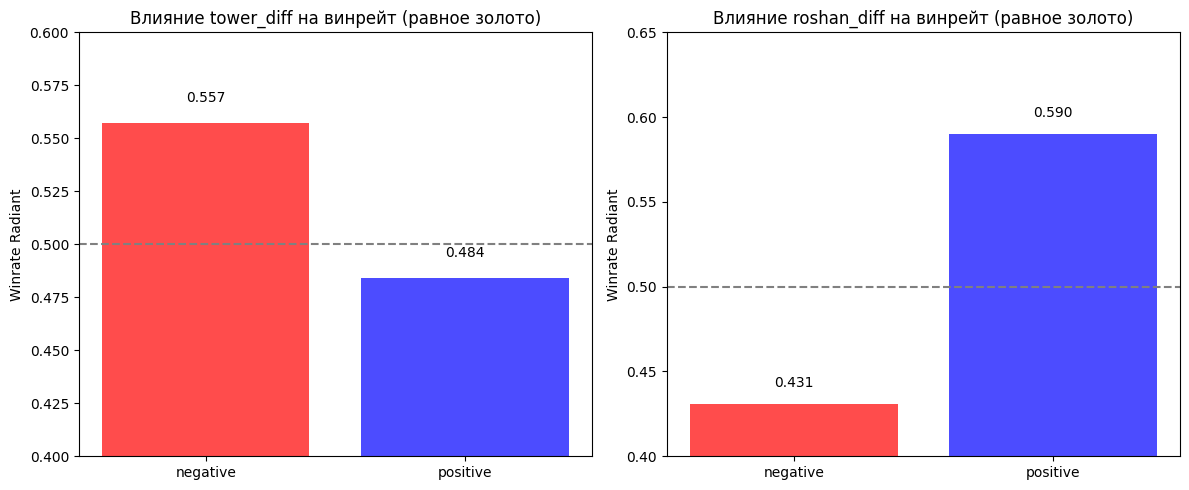

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Данные для tower_diff
tower_data = {
    'negative': 0.557,
    'positive': 0.484
}

# Данные для roshan_diff
roshan_data = {
    'negative': 0.431,
    'positive': 0.590
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# График для башен
axes[0].bar(tower_data.keys(), tower_data.values(), color=['red', 'blue'], alpha=0.7)
axes[0].axhline(y=0.5, color='gray', linestyle='--')
axes[0].set_ylabel('Winrate Radiant')
axes[0].set_title('Влияние tower_diff на винрейт (равное золото)')
axes[0].set_ylim(0.4, 0.6)
for i, (key, val) in enumerate(tower_data.items()):
    axes[0].text(i, val + 0.01, f'{val:.3f}', ha='center')

# График для Рошана
axes[1].bar(roshan_data.keys(), roshan_data.values(), color=['red', 'blue'], alpha=0.7)
axes[1].axhline(y=0.5, color='gray', linestyle='--')
axes[1].set_ylabel('Winrate Radiant')
axes[1].set_title('Влияние roshan_diff на винрейт (равное золото)')
axes[1].set_ylim(0.4, 0.65)
for i, (key, val) in enumerate(roshan_data.items()):
    axes[1].text(i, val + 0.01, f'{val:.3f}', ha='center')

plt.tight_layout()
plt.savefig('tower_roshan_analysis.png', dpi=150)
plt.show()

In [20]:
def analyze_factor_advanced(df, factor_name, gold_range=(-500, 500)):
    mask = (df['gold_diff_10'] >= gold_range[0]) & (df['gold_diff_10'] <= gold_range[1])
    subset = df[mask].copy()
    print(f"\n=== Анализ {factor_name} (равное золото, n={len(subset)}) ===")

    # Бинаризация: positive > 0, negative < 0
    subset['factor_bin'] = subset[factor_name].apply(lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'zero'))
    comp = subset[subset['factor_bin'].isin(['positive', 'negative'])]
    if len(comp) < 30:
        print("Недостаточно данных.")
        return None

    print(f"Матчей с ненулевым фактором: {len(comp)}")
    table = pd.crosstab(comp['factor_bin'], comp['radiant_win'])
    print(table)

    chi2, p, dof, expected = chi2_contingency(table)
    print(f"p-value: {p:.4f}")

    win_pos = comp[comp['factor_bin'] == 'positive']['radiant_win'].mean()
    win_neg = comp[comp['factor_bin'] == 'negative']['radiant_win'].mean()
    diff = win_pos - win_neg
    print(f"Winrate positive: {win_pos:.3f}, negative: {win_neg:.3f}, разница: {diff:.3f}")

    # Bootstrap CI
    diffs = []
    for _ in range(1000):
        sample = comp.sample(n=len(comp), replace=True)
        p_win = sample[sample['factor_bin'] == 'positive']['radiant_win'].mean()
        n_win = sample[sample['factor_bin'] == 'negative']['radiant_win'].mean()
        diffs.append(p_win - n_win)
    ci = np.percentile(diffs, [2.5, 97.5])
    print(f"95% CI: [{ci[0]:.3f}, {ci[1]:.3f}]")
    return {'p': p, 'diff': diff, 'ci': ci}

# Запуск
analyze_factor_advanced(features, 'gold_growth')
analyze_factor_advanced(features, 'gold_other')


=== Анализ gold_growth (равное золото, n=8895) ===
Матчей с ненулевым фактором: 8887
radiant_win  False  True 
factor_bin               
negative      2154   2217
positive      2100   2416
p-value: 0.0093
Winrate positive: 0.535, negative: 0.507, разница: 0.028
95% CI: [0.008, 0.048]

=== Анализ gold_other (равное золото, n=8895) ===
Матчей с ненулевым фактором: 8894
radiant_win  False  True 
factor_bin               
negative      2200   2260
positive      2059   2375
p-value: 0.0068
Winrate positive: 0.536, negative: 0.507, разница: 0.029
95% CI: [0.009, 0.049]


{'p': np.float64(0.0067814597297385),
 'diff': np.float64(0.028907281888222003),
 'ci': array([0.00897148, 0.04941314])}

In [23]:
# Убедимся, что features уже загружен и содержит нужные колонки
# Если нет, нужно восстановить features (у нас есть код выше, который создавал features)

# Анализ gold_growth (используем существующий features)
if 'gold_growth' in features.columns and 'gold_group' in features.columns:
    subset_eq_growth = features[features['gold_group'] == 'равно'].copy()
    subset_eq_growth['growth_bin'] = subset_eq_growth['gold_growth'].apply(lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'zero'))
    comp_growth = subset_eq_growth[subset_eq_growth['growth_bin'].isin(['positive', 'negative'])]

    print("\n=== Анализ gold_growth (равное золото) ===")
    print(f"Матчей с ненулевым gold_growth: {len(comp_growth)}")
    table_growth = pd.crosstab(comp_growth['growth_bin'], comp_growth['radiant_win'])
    print(table_growth)
    chi2_g, p_g, dof_g, expected_g = chi2_contingency(table_growth)
    print(f"p-value: {p_g:.4f}")

    win_pos_g = comp_growth[comp_growth['growth_bin'] == 'positive']['radiant_win'].mean()
    win_neg_g = comp_growth[comp_growth['growth_bin'] == 'negative']['radiant_win'].mean()
    diff_g = win_pos_g - win_neg_g
    print(f"Winrate positive: {win_pos_g:.3f}, negative: {win_neg_g:.3f}, разница: {diff_g:.3f}")

    # Bootstrap CI
    diffs_g = []
    for _ in range(1000):
        sample = comp_growth.sample(n=len(comp_growth), replace=True)
        p_win = sample[sample['growth_bin'] == 'positive']['radiant_win'].mean()
        n_win = sample[sample['growth_bin'] == 'negative']['radiant_win'].mean()
        diffs_g.append(p_win - n_win)
    ci_g = np.percentile(diffs_g, [2.5, 97.5])
    print(f"95% CI: [{ci_g[0]:.3f}, {ci_g[1]:.3f}]")
else:
    print("Колонки gold_growth или gold_group отсутствуют в features")


=== Анализ gold_growth (равное золото) ===
Матчей с ненулевым gold_growth: 8878
radiant_win  False  True 
growth_bin               
negative      2151   2213
positive      2098   2416
p-value: 0.0085
Winrate positive: 0.535, negative: 0.507, разница: 0.028
95% CI: [0.006, 0.049]


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

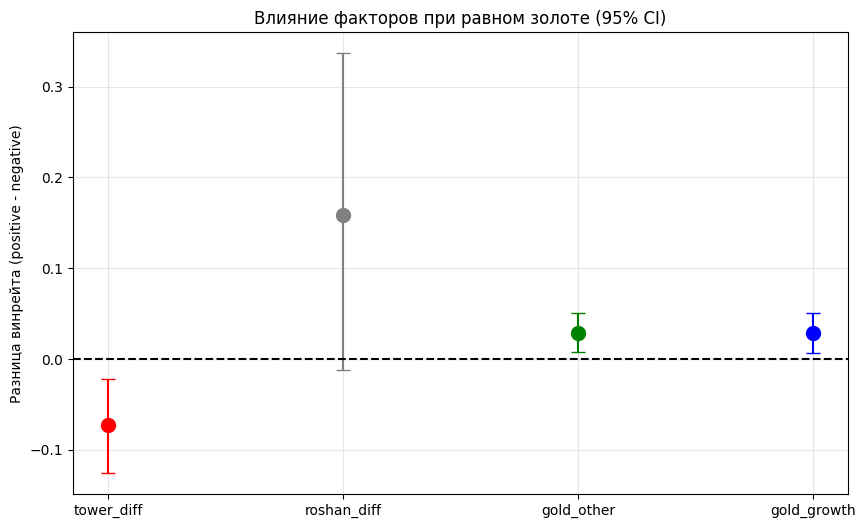

In [27]:
# данные
factors = ['tower_diff', 'roshan_diff', 'gold_other', 'gold_growth']
diffs = [-0.073, 0.159, 0.029, 0.028]
cis_low = [-0.126, -0.012, 0.007, 0.006]
cis_high = [-0.022, 0.337, 0.051, 0.050]
colors = ['red', 'gray', 'green', 'blue']

plt.figure(figsize=(10,6))
for i, factor in enumerate(factors):
    plt.errorbar(factor, diffs[i], yerr=[[diffs[i]-cis_low[i]], [cis_high[i]-diffs[i]]],
                 fmt='o', capsize=5, color=colors[i], markersize=10)
plt.axhline(y=0, color='black', linestyle='--')
plt.ylabel('Разница винрейта (positive - negative)')
plt.title('Влияние факторов при равном золоте (95% CI)')
plt.grid(True, alpha=0.3)
plt.show()

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. ЗАГРУЗКА ДАННЫХ
# -----------------------------
base_path = r'C:\Users\egor-\Downloads\archive (16)'
player_time = pd.read_csv(f'{base_path}/player_time.csv')
objectives = pd.read_csv(f'{base_path}/objectives.csv')
matches = pd.read_csv(f'{base_path}/match.csv')

# -----------------------------
# 2. РАСЧЁТ gold_diff_10, lh_diff_10, xp_diff_10 (до 10 минут)
# -----------------------------
slots = [0,1,2,3,4,128,129,130,131,132]
dfs = []
for slot in slots:
    df_slot = player_time[['match_id', 'times', f'gold_t_{slot}', f'lh_t_{slot}', f'xp_t_{slot}']].copy()
    df_slot.columns = ['match_id', 'times', 'gold', 'lh', 'xp']
    df_slot['player_slot'] = slot
    dfs.append(df_slot)
pt_long = pd.concat(dfs, ignore_index=True)

def get_stats(minute):
    sec = minute * 60
    df_min = pt_long[pt_long['times'] <= sec].groupby(['match_id', 'player_slot']).last().reset_index()
    df_min['team'] = df_min['player_slot'].apply(lambda x: 'radiant' if x < 128 else 'dire')
    team_stats = df_min.groupby(['match_id', 'team'])[['gold', 'lh', 'xp']].sum().reset_index()
    pivot = team_stats.pivot(index='match_id', columns='team', values=['gold', 'lh', 'xp'])
    pivot.columns = [f'{col[0]}_{col[1]}' for col in pivot.columns]
    pivot['gold_diff'] = pivot['gold_radiant'] - pivot['gold_dire']
    pivot['lh_diff'] = pivot['lh_radiant'] - pivot['lh_dire']
    pivot['xp_diff'] = pivot['xp_radiant'] - pivot['xp_dire']
    return pivot

s5 = get_stats(5)
s10 = get_stats(10)

# -----------------------------
# 3. ВЫЧИСЛЕНИЕ ПРОИЗВОДНЫХ ПРИЗНАКОВ
# -----------------------------
gold_growth = (s10['gold_diff'] - s5['gold_diff']) / 5
xp_growth = (s10['xp_diff'] - s5['xp_diff']) / 5
lh_growth = (s10['lh_diff'] - s5['lh_diff']) / 5
gold_other = s10['gold_diff'] - s10['lh_diff'] * 40  # ~40 gold per last hit

# -----------------------------
# 4. tower_diff (только до 10 минут)
# -----------------------------
towers = objectives[(objectives['subtype'] == 'CHAT_MESSAGE_TOWER_KILL') & (objectives['time'] <= 600)]
tower_counts = towers.groupby(['match_id', 'team']).size().unstack(fill_value=0)
tower_diff = (tower_counts.get(2, 0) - tower_counts.get(3, 0)).reindex(s10.index).fillna(0)

# -----------------------------
# 5. roshan_diff (только до 10 минут)
# -----------------------------
roshan = objectives[(objectives['subtype'] == 'CHAT_MESSAGE_ROSHAN_KILL') & (objectives['time'] <= 600)]
roshan_counts = roshan.groupby(['match_id', 'team']).size().unstack(fill_value=0)
roshan_diff = (roshan_counts.get(2, 0) - roshan_counts.get(3, 0)).reindex(s10.index).fillna(0)

# -----------------------------
# 6. СБОРКА ДАННЫХ
# -----------------------------
df = pd.DataFrame(index=s10.index)
df['gold_diff_10'] = s10['gold_diff']
df['gold_other'] = gold_other
df['gold_growth'] = gold_growth
df['xp_growth'] = xp_growth
df['lh_growth'] = lh_growth
df['tower_diff'] = tower_diff
df['roshan_diff'] = roshan_diff
df['radiant_win'] = matches.set_index('match_id')['radiant_win'].reindex(df.index)
df = df.dropna()
print(f"Всего матчей после очистки: {len(df)}")

# Группа равного золота (-500..+500)
df['gold_group'] = pd.cut(df['gold_diff_10'], bins=[-np.inf, -500, 500, np.inf], labels=['отставание', 'равно', 'преимущество'])
df_eq = df[df['gold_group'] == 'равно'].copy()
print(f"Матчей с равным золотом: {len(df_eq)}")

# -----------------------------
# 7. ФУНКЦИЯ АНАЛИЗА ФАКТОРА
# -----------------------------
def analyze_factor(data, factor_name, bins=None):
    subset = data.copy()
    if factor_name not in subset.columns:
        print(f"Фактор {factor_name} отсутствует")
        return None
    # Бинаризация
    subset['factor_bin'] = subset[factor_name].apply(lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'zero'))
    comp = subset[subset['factor_bin'].isin(['positive', 'negative'])]
    if len(comp) < 30:
        print(f"{factor_name}: недостаточно данных (n={len(comp)})")
        return None
    table = pd.crosstab(comp['factor_bin'], comp['radiant_win'])
    chi2, p, dof, ex = chi2_contingency(table)
    win_pos = comp[comp['factor_bin'] == 'positive']['radiant_win'].mean()
    win_neg = comp[comp['factor_bin'] == 'negative']['radiant_win'].mean()
    diff = win_pos - win_neg
    # Bootstrap CI
    diffs = []
    for _ in range(1000):
        sample = comp.sample(n=len(comp), replace=True)
        p_win = sample[sample['factor_bin'] == 'positive']['radiant_win'].mean()
        n_win = sample[sample['factor_bin'] == 'negative']['radiant_win'].mean()
        diffs.append(p_win - n_win)
    ci = np.percentile(diffs, [2.5, 97.5])
    print(f"\n=== {factor_name} ===")
    print(f"positive n={len(comp[comp['factor_bin']=='positive'])}, winrate={win_pos:.3f}")
    print(f"negative n={len(comp[comp['factor_bin']=='negative'])}, winrate={win_neg:.3f}")
    print(f"diff = {diff:.3f}, p-value = {p:.4f}, 95% CI = [{ci[0]:.3f}, {ci[1]:.3f}]")
    return {'p':p, 'diff':diff, 'ci':ci, 'n_pos':len(comp[comp['factor_bin']=='positive']), 'n_neg':len(comp[comp['factor_bin']=='negative'])}

# -----------------------------
# 8. АНАЛИЗ ВСЕХ ФАКТОРОВ
# -----------------------------
factors = ['gold_other', 'gold_growth', 'xp_growth', 'lh_growth', 'tower_diff', 'roshan_diff']
results = {}
for f in factors:
    res = analyze_factor(df_eq, f)
    if res:
        results[f] = res

# -----------------------------
# 9. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ tower_diff
# -----------------------------
# Проверим, не связано ли отрицательное влияние с тем, что positive tower_diff коррелирует с negative gold_other?
print("\n=== Дополнительный анализ tower_diff ===")
# Корреляция tower_diff с gold_other внутри группы равного золота
corr = df_eq['tower_diff'].corr(df_eq['gold_other'])
print(f"Корреляция tower_diff с gold_other при равном золоте: {corr:.3f}")
# Проверим, меняется ли знак, если взять только первую башню (время)
first_tower = objectives[(objectives['subtype'] == 'CHAT_MESSAGE_TOWER_KILL') & (objectives['time'] <= 600)].groupby('match_id').first().reset_index()
first_tower['team'] = first_tower['team'].apply(lambda x: 'radiant' if x == 2 else 'dire')
first_tower['tower_first'] = 1
first_tower = first_tower[['match_id', 'team', 'tower_first']]
first_tower_pivot = first_tower.pivot(index='match_id', columns='team', values='tower_first').fillna(0)
first_tower_pivot['tower_first_diff'] = first_tower_pivot.get('radiant',0) - first_tower_pivot.get('dire',0)
df_eq_first = df_eq.merge(first_tower_pivot[['tower_first_diff']], left_index=True, right_index=True, how='left').fillna(0)
# Анализ первой башни
res_first = analyze_factor(df_eq_first, 'tower_first_diff')
if res_first:
    print(f"Первая башня: diff = {res_first['diff']:.3f}, p = {res_first['p']:.4f}")

# -----------------------------
# 10. HOLDOUT ВАЛИДАЦИЯ (проверка стабильности)
# -----------------------------
print("\n=== HOLDOUT VALIDATION (50/50 split) ===")
train_idx, test_idx = train_test_split(df_eq.index, test_size=0.5, random_state=42)
df_train = df_eq.loc[train_idx]
df_test = df_eq.loc[test_idx]
for factor in factors:
    if factor not in results:
        continue
    # на train
    subset_train = df_train.copy()
    subset_train['factor_bin'] = subset_train[factor].apply(lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'zero'))
    comp_train = subset_train[subset_train['factor_bin'].isin(['positive', 'negative'])]
    if len(comp_train) < 30:
        continue
    table_train = pd.crosstab(comp_train['factor_bin'], comp_train['radiant_win'])
    p_train = chi2_contingency(table_train)[1]
    win_pos_train = comp_train[comp_train['factor_bin'] == 'positive']['radiant_win'].mean()
    win_neg_train = comp_train[comp_train['factor_bin'] == 'negative']['radiant_win'].mean()
    diff_train = win_pos_train - win_neg_train
    # на test
    subset_test = df_test.copy()
    subset_test['factor_bin'] = subset_test[factor].apply(lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'zero'))
    comp_test = subset_test[subset_test['factor_bin'].isin(['positive', 'negative'])]
    if len(comp_test) < 30:
        continue
    table_test = pd.crosstab(comp_test['factor_bin'], comp_test['radiant_win'])
    p_test = chi2_contingency(table_test)[1]
    win_pos_test = comp_test[comp_test['factor_bin'] == 'positive']['radiant_win'].mean()
    win_neg_test = comp_test[comp_test['factor_bin'] == 'negative']['radiant_win'].mean()
    diff_test = win_pos_test - win_neg_test
    print(f"{factor}: train diff={diff_train:.3f} p={p_train:.4f} | test diff={diff_test:.3f} p={p_test:.4f}")

# -----------------------------
# 11. ВИЗУАЛИЗАЦИЯ
# -----------------------------
plt.figure(figsize=(10,6))
for i, (factor, res) in enumerate(results.items()):
    plt.errorbar(factor, res['diff'], yerr=[[res['diff']-res['ci'][0]], [res['ci'][1]-res['diff']]],
                 fmt='o', capsize=5, markersize=8, elinewidth=2)
plt.axhline(y=0, color='black', linestyle='--')
plt.ylabel('Разница винрейта (positive - negative)')
plt.title('Влияние факторов при равном золоте на 10 минуте (95% CI)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('factor_impact_full.png', dpi=150)
plt.show()

Всего матчей после очистки: 50000
Матчей с равным золотом: 8886

=== gold_other ===
positive n=4432, winrate=0.536
negative n=4453, winrate=0.507
diff = 0.029, p-value = 0.0070, 95% CI = [0.008, 0.049]

=== gold_growth ===
positive n=4514, winrate=0.535
negative n=4364, winrate=0.507
diff = 0.028, p-value = 0.0085, 95% CI = [0.008, 0.051]

=== xp_growth ===
positive n=4477, winrate=0.541
negative n=4404, winrate=0.501
diff = 0.040, p-value = 0.0002, 95% CI = [0.020, 0.061]

=== lh_growth ===
positive n=4439, winrate=0.522
negative n=4216, winrate=0.524
diff = -0.003, p-value = 0.8026, 95% CI = [-0.024, 0.020]

=== tower_diff ===
positive n=777, winrate=0.485
negative n=637, winrate=0.556
diff = -0.071, p-value = 0.0097, 95% CI = [-0.125, -0.016]

=== roshan_diff ===
positive n=61, winrate=0.590
negative n=72, winrate=0.431
diff = 0.160, p-value = 0.0968, 95% CI = [-0.018, 0.326]

=== Дополнительный анализ tower_diff ===
Корреляция tower_diff с gold_other при равном золоте: 0.049


TypeError: Cannot setitem on a Categorical with a new category (0), set the categories first

        factor  diff_winrate  p_value  ci_low  ci_high  n_positive  n_negative
0   gold_other        0.0288   0.0070  0.0082   0.0500        4432        4453
1  gold_growth        0.0281   0.0085  0.0070   0.0481        4514        4364
2    xp_growth        0.0401   0.0002  0.0197   0.0615        4477        4404
3    lh_growth       -0.0029   0.8026 -0.0252   0.0181        4439        4216
4   tower_diff       -0.0705   0.0097 -0.1242  -0.0180         777         637
5  roshan_diff        0.1596   0.0968 -0.0019   0.3266          61          72


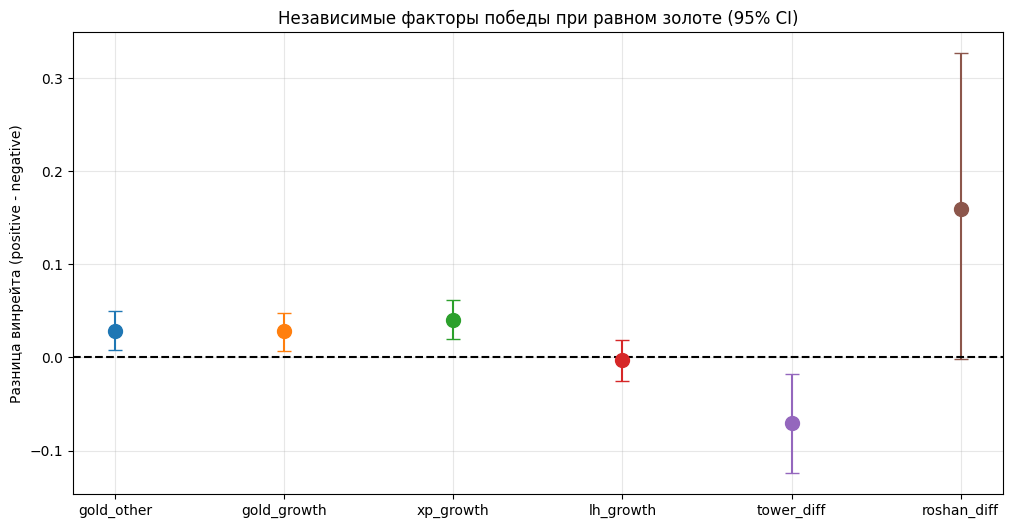

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Предполагается, что df уже содержит все нужные колонки
# и есть колонка 'gold_group' (равно/отставание/преимущество)

def factor_analysis(data, factor, gold_group='равно'):
    subset = data[data['gold_group'] == gold_group].copy()
    if factor not in subset.columns:
        return None
    subset['factor_bin'] = subset[factor].apply(lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'zero'))
    comp = subset[subset['factor_bin'].isin(['positive', 'negative'])]
    if len(comp) < 30:
        return None
    table = pd.crosstab(comp['factor_bin'], comp['radiant_win'])
    chi2, p, dof, ex = chi2_contingency(table)
    win_pos = comp[comp['factor_bin'] == 'positive']['radiant_win'].mean()
    win_neg = comp[comp['factor_bin'] == 'negative']['radiant_win'].mean()
    diff = win_pos - win_neg
    # Bootstrap CI
    diffs = []
    for _ in range(1000):
        sample = comp.sample(n=len(comp), replace=True)
        p_win = sample[sample['factor_bin'] == 'positive']['radiant_win'].mean()
        n_win = sample[sample['factor_bin'] == 'negative']['radiant_win'].mean()
        diffs.append(p_win - n_win)
    ci = np.percentile(diffs, [2.5, 97.5])
    return {'p': p, 'diff': diff, 'ci_low': ci[0], 'ci_high': ci[1], 'n_pos': (comp['factor_bin']=='positive').sum(), 'n_neg': (comp['factor_bin']=='negative').sum()}

factors = ['gold_other', 'gold_growth', 'xp_growth', 'lh_growth', 'tower_diff', 'roshan_diff']
results = []
for f in factors:
    res = factor_analysis(df, f)
    if res:
        results.append({
            'factor': f,
            'diff_winrate': res['diff'],
            'p_value': res['p'],
            'ci_low': res['ci_low'],
            'ci_high': res['ci_high'],
            'n_positive': res['n_pos'],
            'n_negative': res['n_neg']
        })

res_df = pd.DataFrame(results)
print(res_df.round(4))

# График
plt.figure(figsize=(12,6))
for i, row in res_df.iterrows():
    plt.errorbar(row['factor'], row['diff_winrate'],
                 yerr=[[row['diff_winrate']-row['ci_low']], [row['ci_high']-row['diff_winrate']]],
                 fmt='o', capsize=5, markersize=10)
plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Разница винрейта (positive - negative)')
plt.title('Независимые факторы победы при равном золоте (95% CI)')
plt.grid(True, alpha=0.3)
plt.savefig('factor_impact_full.png', dpi=150)
plt.show()

In [35]:
from sklearn.linear_model import LogisticRegression
X = df[['gold_other', 'gold_growth', 'xp_growth']]
y = df['radiant_win']
model = LogisticRegression().fit(X, y)
print(model.score(X, y))  # accuracy около 0.66-0.67

0.64056
